In [3]:
import os
import re
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from IPython.display import display
from scipy.stats import loguniform, randint, uniform
from sklearn.base import clone
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    silhouette_samples,
    silhouette_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    KFold,
    RandomizedSearchCV,
    learning_curve,
    train_test_split,
    validation_curve,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVR
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2


def save_and_show(filename, dpi=300):
    """Save the active figure once, display it, then close it to avoid duplicate/stale saves."""
    plt.savefig(filename, dpi=dpi, bbox_inches="tight")
    plt.show()
    plt.close()

## 1. Loading data

In [ ]:
df = pd.read_csv("data/housing.csv")
print(df.head())

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                  41          880           129.0   
1    -122.22     37.86                  21         7099          1106.0   
2    -122.24     37.85                  52         1467           190.0   
3    -122.25     37.85                  52         1274           235.0   
4    -122.25     37.85                  52         1627           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0         322         126         8.3252              452600        NEAR BAY  
1        2401        1138         8.3014              358500        NEAR BAY  
2         496         177         7.2574              352100        NEAR BAY  
3         558         219         5.6431              341300        NEAR BAY  
4         565         259         3.8462              342200        NEAR BAY  


In [5]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  int64  
 3   total_rooms         20640 non-null  int64  
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  int64  
 6   households          20640 non-null  int64  
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  int64  
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(4), int64(5), object(1)
memory usage: 1.6+ MB


,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


## 1.1 Managing missing values

In [6]:
# Removing rows with missing values as it is insufficient number of rows to impute
df = df.dropna()
df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


## 1.2 Encoding categorical features

In [7]:
# Encoding categorical features using one-hot encoding
df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000
mean,-119.570689,35.633221,28.633094,2636.504233,537.870553,1424.946949,499.433465,3.871162,206864.413155
std,2.003578,2.136348,12.591805,2185.269567,421.385070,1133.208490,382.299226,1.899291,115435.667099
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1450.000000,296.000000,787.000000,280.000000,2.563700,119500.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.536500,179700.000000
75%,-118.010000,37.720000,37.000000,3143.000000,647.000000,1722.000000,604.000000,4.744000,264700.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


## 1.3 Exploratory data analysis and feature engineering

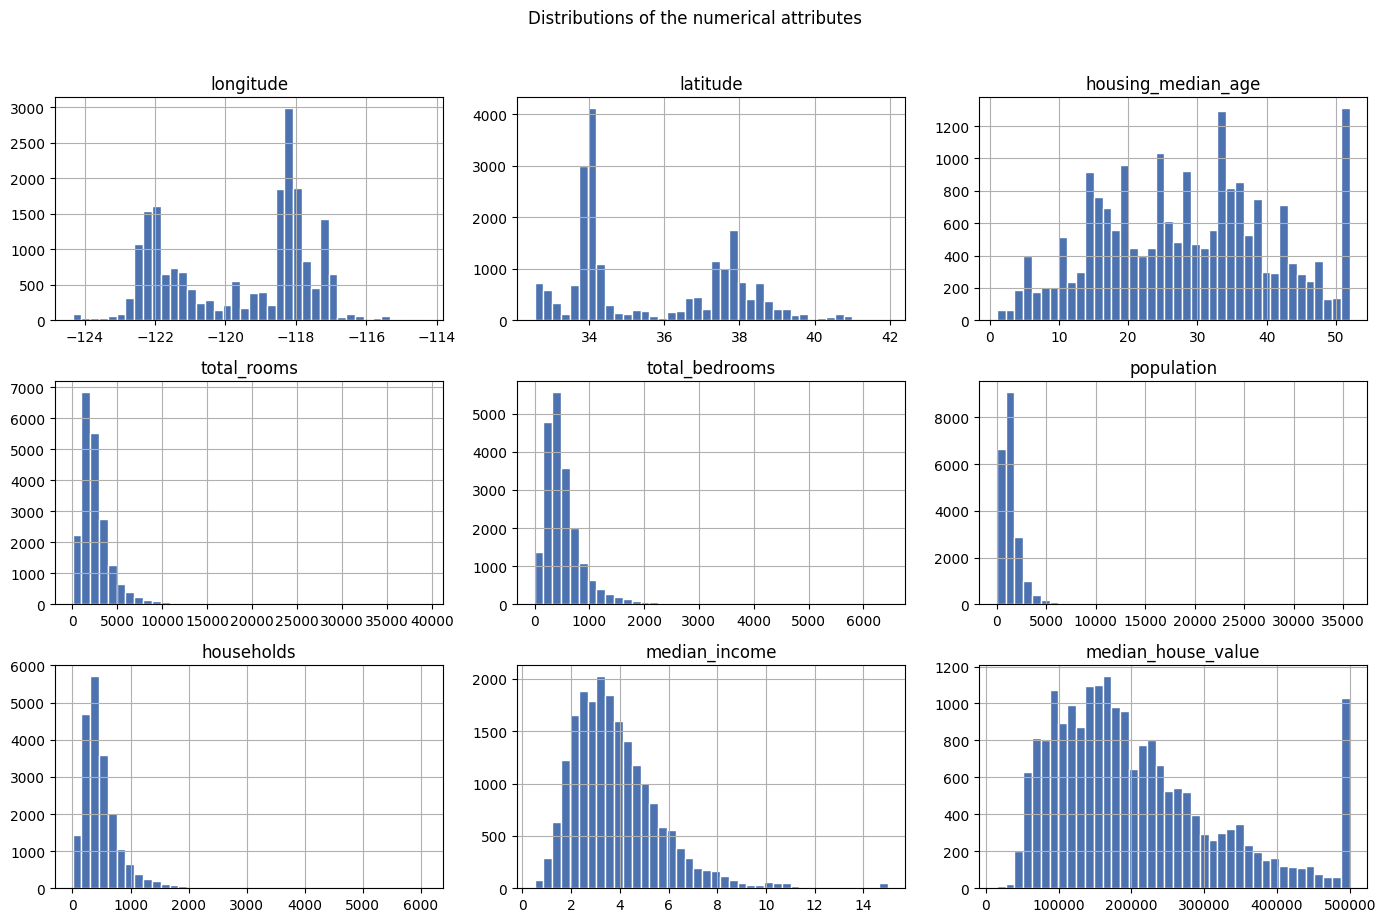

In [8]:
# Distribution of features
df.hist(bins=40, figsize=(14, 9), color="#4C72B0", edgecolor="white")
plt.suptitle("Distributions of the numerical attributes", y=1.02)
plt.tight_layout()
save_and_show("distributions_numerical_attributes.png")


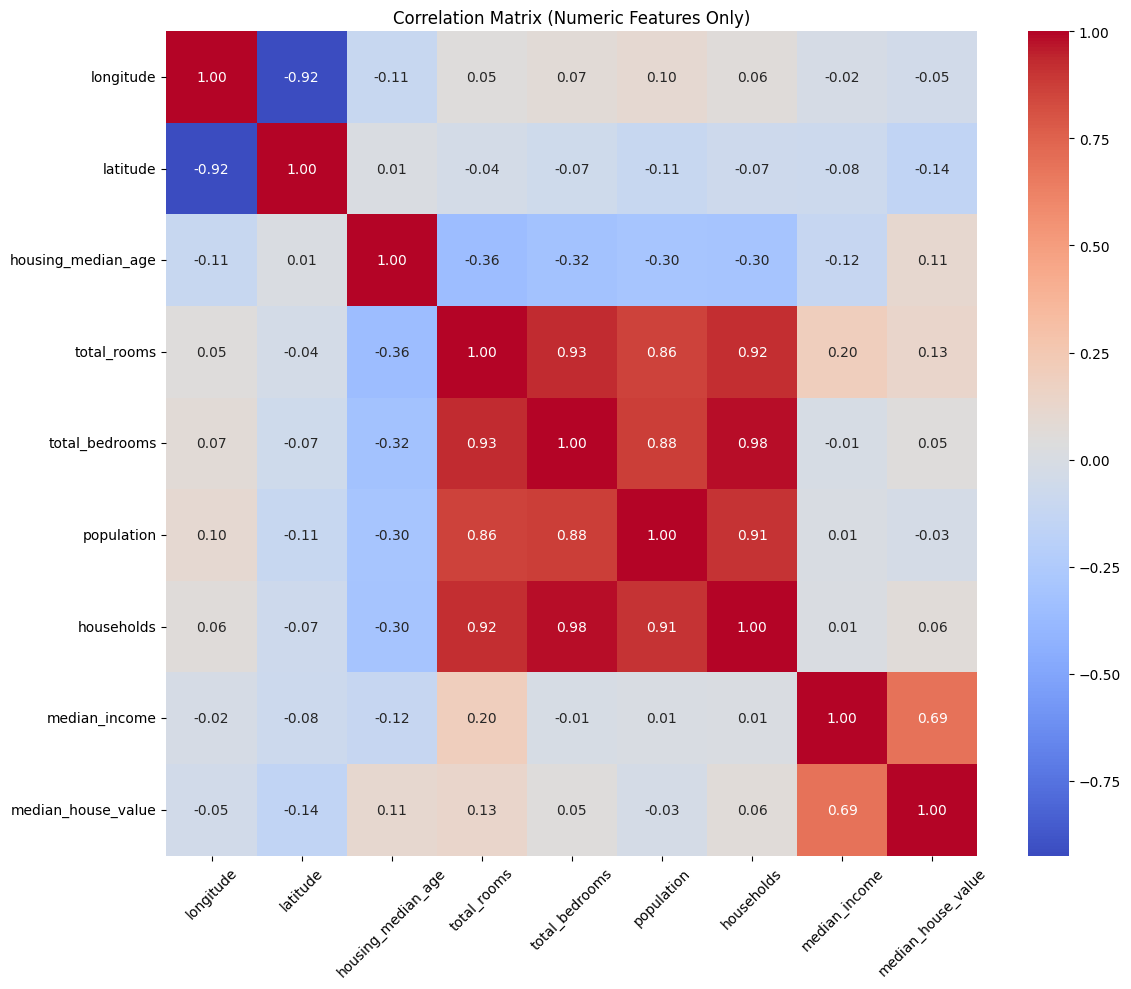

In [9]:
# Correlation matrix (numeric features only, excluding categorical columns)
plt.figure(figsize=(12, 10))
numeric_df = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix (Numeric Features Only)')
plt.xticks(rotation=45)
plt.tight_layout()
save_and_show("correlation_matrix.png")


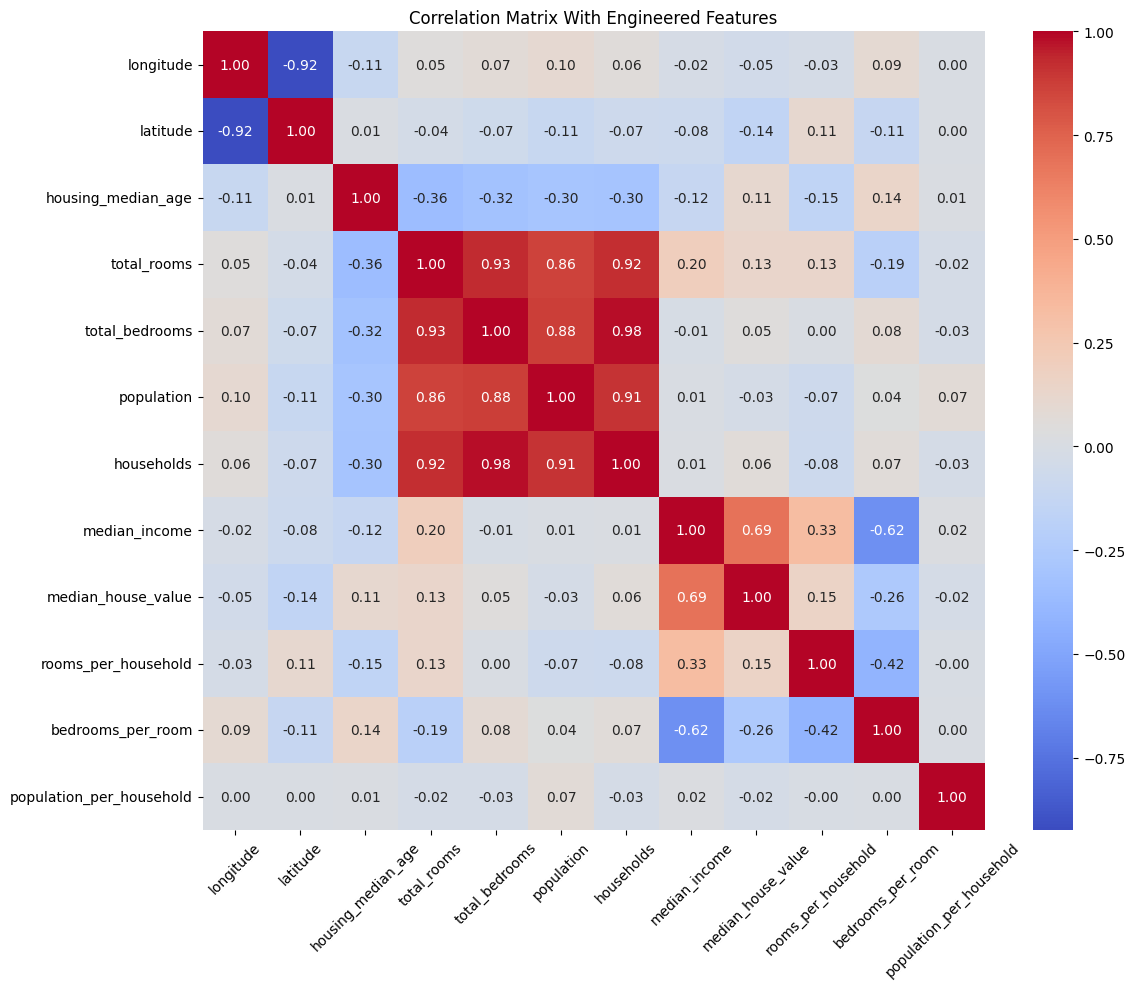

In [10]:
# Feature engineering: Creating new features based on existing ones
"""
    Creating new features based on existing ones to improve the model's performance.
    For example, creating a new feature 'rooms_per_household' by dividing 'total_rooms' by 'households'.
"""
df['rooms_per_household'] = df['total_rooms'] / df['households']
df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']
df['population_per_household'] = df['population'] / df['households']

plt.figure(figsize=(12, 10))
numeric_df = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix With Engineered Features')
plt.xticks(rotation=45)
plt.tight_layout()
save_and_show("correlation_matrix_with_new_features.png")


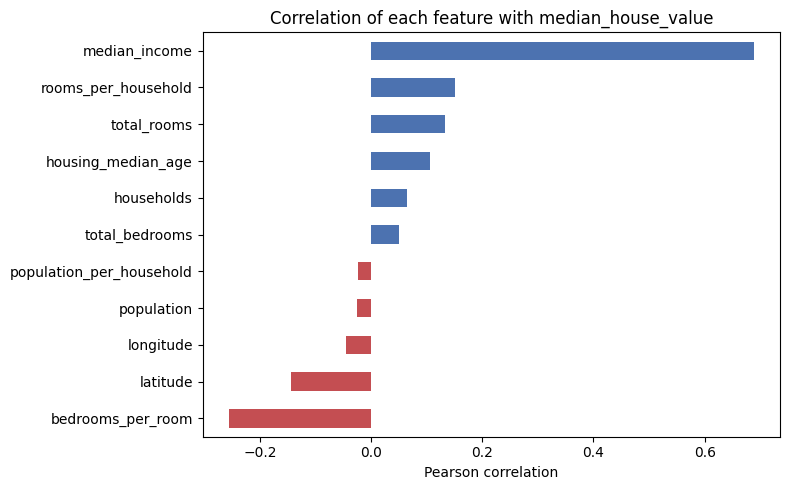

bedrooms_per_room          -0.256
latitude                   -0.145
longitude                  -0.045
population                 -0.025
population_per_household   -0.024
total_bedrooms              0.050
households                  0.065
housing_median_age          0.106
total_rooms                 0.133
rooms_per_household         0.151
median_income               0.688


In [11]:
# Correlation of each feature with the target variable (median_house_value)
target_corr = df.select_dtypes(include=[np.number]).corr()["median_house_value"].drop("median_house_value").sort_values()
fig, ax = plt.subplots(figsize=(8, 5))
target_corr.plot(kind="barh", color=np.where(target_corr > 0, "#4C72B0", "#C44E52"), ax=ax)
ax.set(title="Correlation of each feature with median_house_value", xlabel="Pearson correlation")
plt.tight_layout()
save_and_show("correlation_with_target_variable.png")
print(target_corr.round(3).to_string())


## 1.5 Train test split

In [ ]:
# Splitting the dataset into features and target variable
X = df.drop("median_house_value", axis=1)
y = df["median_house_value"]

# Splitting the dataset into training and testing sets
# Stratification is not used because this is a regression target.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# 2 Clustering

## 2.1 K-mean clustering

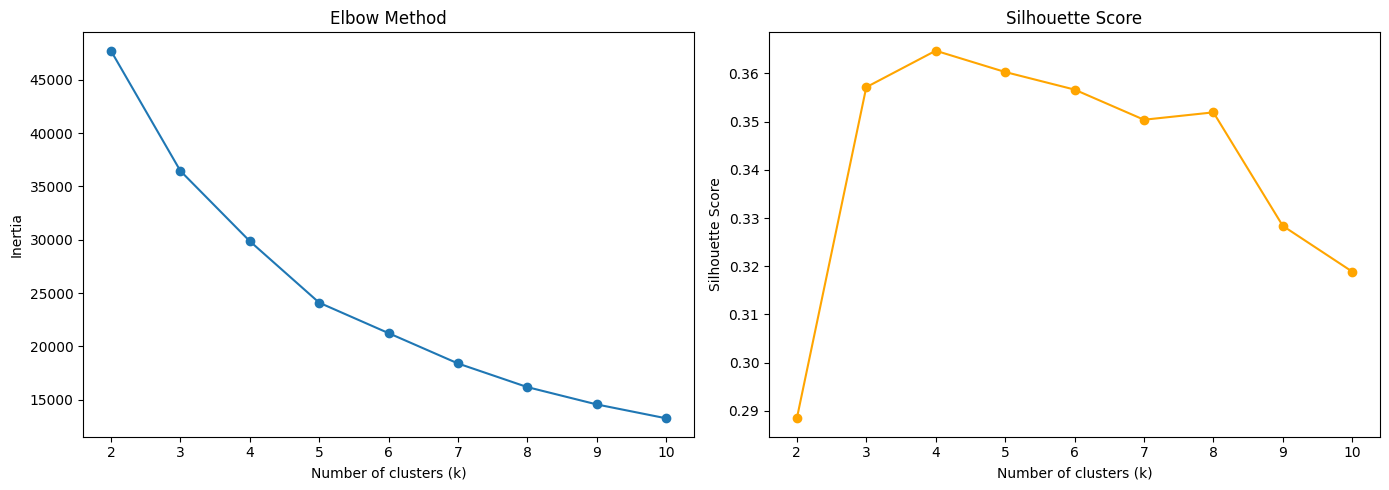

In [13]:
# Selecting the most important features based on correlation with the target variable
CLUSTER_FEATURES = ['median_income', 'rooms_per_household', 'bedrooms_per_room', 'latitude']

# Scale clustering features only on the training data
scaler_cluster = StandardScaler()
X_train_cluster = scaler_cluster.fit_transform(X_train[CLUSTER_FEATURES])

# Choosing the k for KMeans clustering based on silhouette score and elbow method
inertia, silhouette_scores = [], []
k_range = range(2, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_train_cluster)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_train_cluster, kmeans.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow method plot
axes[0].plot(k_range, inertia, marker='o')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia')

# Silhouette score plot
axes[1].plot(k_range, silhouette_scores, marker='o', color='orange')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
save_and_show("kmeans_elbow_silhouette.png")


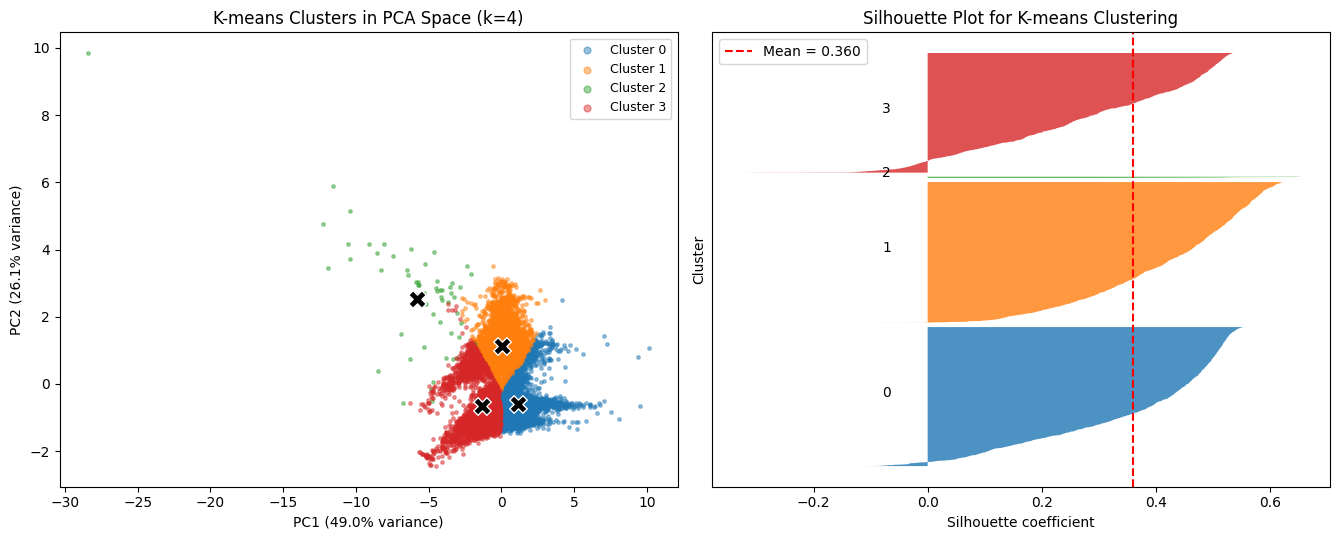

Training cluster counts:
0    5748
1    5721
2      61
3    4816
Name: count, dtype: int64

Mean silhouette score: 0.360


In [ ]:
# Select features for clustering
CLUSTER_FEATURES = ['median_income', 'rooms_per_household', 'bedrooms_per_room', 'latitude']

# Scale clustering features
scaler_cluster = StandardScaler()
X_train_cluster = scaler_cluster.fit_transform(X_train[CLUSTER_FEATURES])

# K-means with k = 4
K_OPT = 4
kmeans_final = KMeans(n_clusters=K_OPT, random_state=42, n_init=10)
train_cl = kmeans_final.fit_predict(X_train_cluster)

# PCA projection for 2D visualisation
pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train_cluster)
centers_pca = pca.transform(kmeans_final.cluster_centers_)

# Colour palette
palette = sns.color_palette("tab10", K_OPT)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.5))

# Plot 1: PCA cluster plot
for c in range(K_OPT):
    mask = train_cl == c
    axes[0].scatter(
        X_train_pca[mask, 0],
        X_train_pca[mask, 1],
        s=6,
        alpha=0.45,
        color=palette[c],
        label=f"Cluster {c}"
    )

# Draw centroids but keep them out of legend
axes[0].scatter(
    centers_pca[:, 0],
    centers_pca[:, 1],
    marker='X',
    s=160,
    c='black',
    edgecolors='white',
    linewidths=1,
    label='_nolegend_'
)

# Label axes with explained variance ratio
exp_var = pca.explained_variance_ratio_ * 100
axes[0].set_xlabel(f"PC1 ({exp_var[0]:.1f}% variance)")
axes[0].set_ylabel(f"PC2 ({exp_var[1]:.1f}% variance)")
axes[0].set_title(f"K-means Clusters in PCA Space (k={K_OPT})")
axes[0].legend(markerscale=2, fontsize=9)

# Plot 2: Silhouette coefficient plot
# Use a sample to make the silhouette plot faster
rng = np.random.default_rng(42)
sample_size = min(4000, len(X_train_cluster))
samp = rng.choice(len(X_train_cluster), sample_size, replace=False)

X_sample = X_train_cluster[samp]
labels_sample = train_cl[samp]

sil_vals = silhouette_samples(X_sample, labels_sample)
mean_sil = silhouette_score(X_sample, labels_sample)

y_lower = 10

for c in range(K_OPT):
    vals = np.sort(sil_vals[labels_sample == c])

    axes[1].fill_betweenx(
        np.arange(y_lower, y_lower + len(vals)),
        0,
        vals,
        facecolor=palette[c],
        alpha=0.8
    )

    axes[1].text(-0.08, y_lower + 0.5 * len(vals), str(c))
    y_lower += len(vals) + 40

axes[1].axvline(
    mean_sil,
    color="red",
    linestyle="--",
    label=f"Mean = {mean_sil:.3f}"
)

axes[1].set_xlabel("Silhouette coefficient")
axes[1].set_ylabel("Cluster")
axes[1].set_title("Silhouette Plot for K-means Clustering")
axes[1].set_yticks([])
axes[1].legend()

plt.tight_layout()
save_and_show("kmeans_pca_silhouette.png")

# Check cluster counts
print("Training cluster counts:")
print(pd.Series(train_cl).value_counts().sort_index())

print(f"\nMean silhouette score: {mean_sil:.3f}")

## 2.2 K-Nearest Neighbours (KNN)
Adding CL to the training set and transferring it to the test set with KNN

In [ ]:
# Train a KNN classifier to predict cluster labels for the test set
knn = KNeighborsClassifier(n_neighbors=5).fit(X_train_cluster, train_cl)
test_cl = knn.predict(scaler_cluster.transform(X_test[CLUSTER_FEATURES]))
knn_train_agreement = (knn.predict(X_train_cluster) == train_cl).mean()
print(f"KNN reproduces the K-means labels on the training set for " f"{knn_train_agreement:.1%} of records")
print("\nCluster sizes (share of records):")
print(pd.DataFrame({ "train": pd.Series(train_cl).value_counts(normalize=True).sort_index().round(3),
                    "test (via KNN)": pd.Series(test_cl).value_counts(normalize=True).sort_index().round(3), }).to_string())


# K-means + KNN cluster assignment
# Visualise train and test clusters
# Features used for clustering
CLUSTER_FEATURES = ['median_income', 'rooms_per_household', 'bedrooms_per_room', 'latitude']

# Scale clustering features
scaler_cluster = StandardScaler()
X_train_cluster = scaler_cluster.fit_transform(X_train[CLUSTER_FEATURES])
X_test_cluster = scaler_cluster.transform(X_test[CLUSTER_FEATURES])

# K-means on training set only
K_OPT = 4
kmeans = KMeans(n_clusters=K_OPT, random_state=42, n_init=10)
train_cl = kmeans.fit_predict(X_train_cluster)

# KNN assigns cluster labels to test set
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_cluster, train_cl)
test_cl = knn.predict(X_test_cluster)

# Check KNN agreement on training data
knn_train_agreement = (knn.predict(X_train_cluster) == train_cl).mean()

print(f"KNN reproduces the K-means labels on the training set for {knn_train_agreement:.1%} of records")

print("\nCluster sizes (share of records):")
print(pd.DataFrame({
    "train": pd.Series(train_cl).value_counts(normalize=True).sort_index().round(3),
    "test (via KNN)": pd.Series(test_cl).value_counts(normalize=True).sort_index().round(3),
}).to_string())



KNN reproduces the K-means labels on the training set for 99.2% of records

Cluster sizes (share of records):
   train  test (via KNN)
0  0.352           0.361
1  0.350           0.337
2  0.004           0.005
3  0.295           0.297
KNN reproduces the K-means labels on the training set for 99.2% of records

Cluster sizes (share of records):
   train  test (via KNN)
0  0.352           0.361
1  0.350           0.337
2  0.004           0.005
3  0.295           0.297


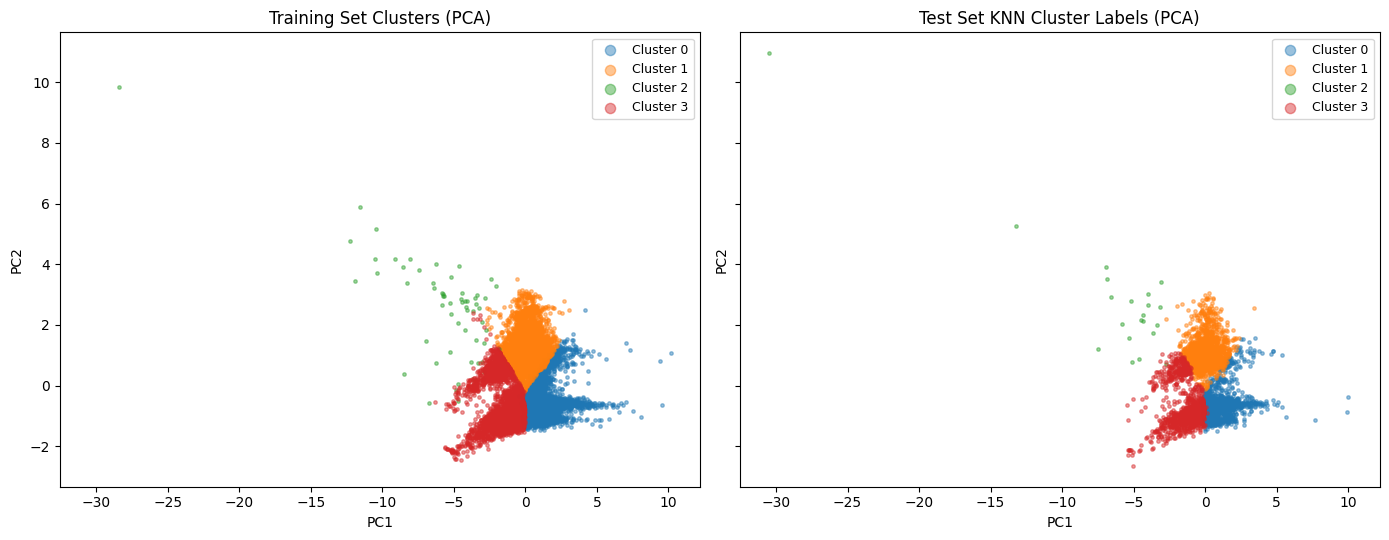

In [16]:
# PCA visualisation for KNN-assigned clusters (train and test)
# Uses the same clustering feature space as KMeans/KNN.
pca_knn = PCA(n_components=2, random_state=42)
X_train_knn_2d = pca_knn.fit_transform(X_train_cluster)
X_test_knn_2d = pca_knn.transform(X_test_cluster)

palette = sns.color_palette("tab10", K_OPT)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharex=True, sharey=True)

# Train set cluster plot in PCA space
for c in range(K_OPT):
    mask = (train_cl == c)
    axes[0].scatter(
        X_train_knn_2d[mask, 0],
        X_train_knn_2d[mask, 1],
        s=6,
        alpha=0.45,
        color=palette[c],
        label=f"Cluster {c}"
    )

axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].set_title("Training Set Clusters (PCA)")
axes[0].legend(markerscale=3, fontsize=9)

# Test set cluster plot in PCA space (labels assigned by KNN)
for c in range(K_OPT):
    mask = (test_cl == c)
    axes[1].scatter(
        X_test_knn_2d[mask, 0],
        X_test_knn_2d[mask, 1],
        s=6,
        alpha=0.45,
        color=palette[c],
        label=f"Cluster {c}"
    )

axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].set_title("Test Set KNN Cluster Labels (PCA)")
axes[1].legend(markerscale=3, fontsize=9)

plt.tight_layout()
save_and_show("train_test_clusters_pca_knn.png")

In [17]:
# Add K-means/KNN cluster labels to the regression feature set
# This cell overwrites X_train_scaled and X_test_scaled so all regression models use the cluster-label feature data.

X_train_with_cl = X_train.copy()
X_test_with_cl = X_test.copy()

X_train_with_cl["cluster_label"] = train_cl
X_test_with_cl["cluster_label"] = test_cl

# One-hot encode the cluster label because it is a categorical feature
X_train_with_cl = pd.get_dummies(X_train_with_cl, columns=["cluster_label"], prefix="CL")
X_test_with_cl = pd.get_dummies(X_test_with_cl, columns=["cluster_label"], prefix="CL")

# Make sure train and test have exactly the same columns
X_train_with_cl, X_test_with_cl = X_train_with_cl.align(
    X_test_with_cl, join="left", axis=1, fill_value=0
)

# Save the final feature names for Random Forest feature importance
regression_feature_names = X_train_with_cl.columns

# Scale once for regression models
scaler_reg = StandardScaler()
X_train_scaled = scaler_reg.fit_transform(X_train_with_cl)
X_test_scaled = scaler_reg.transform(X_test_with_cl)

print("Regression features now include cluster labels:")
print([c for c in X_train_with_cl.columns if c.startswith("CL_")])
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)


Regression features now include cluster labels:
['CL_0', 'CL_1', 'CL_2', 'CL_3']
X_train_scaled shape: (16346, 19)
X_test_scaled shape: (4087, 19)


## 3 Regression Models

In [18]:
# Evaluation of regression models
# Dictionary to store performance metrics for each regression model (for later comparison)
regression_results = {}

def evaluate_regression(model_name, y_train_true, y_train_pred, y_test_true, y_test_pred):
    """Compute RMSE, MAE and R^2 for both training and test predictions, store and print them."""
    def _metrics(y_true, y_pred):
        return {
            'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
            'MAE': mean_absolute_error(y_true, y_pred),
            'R2': r2_score(y_true, y_pred)
        }

    train_metrics = _metrics(y_train_true, y_train_pred)
    test_metrics = _metrics(y_test_true, y_test_pred)

    regression_results[model_name] = {'train': train_metrics, 'test': test_metrics}

    model_table = pd.DataFrame([train_metrics, test_metrics], index=['Train', 'Test'])
    model_table = model_table[['RMSE', 'MAE', 'R2']].round({'RMSE': 2, 'MAE': 2, 'R2': 4})

    print(f"\n{model_name} Performance:")
    print(model_table.to_string())

    return regression_results[model_name]

# Downsample the training data for hyperparameter tuning to speed up the process
X_search, _, y_search, _ = train_test_split(X_train_scaled, y_train, test_size=0.5, random_state=42)

## 3.1 Linear Regression

In [19]:
# Define the parameters for grid search for Linear Regression
lr_param_grid = {
    'fit_intercept': [True, False],
    'positive': [True, False]
}

# K-fold cross-validation splitter
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Grid search for Linear Regression
lr_grid_search = GridSearchCV(
    estimator=LinearRegression(),
    param_grid=lr_param_grid,
    scoring='neg_root_mean_squared_error',
    cv=kfold,
    n_jobs=-1
)

# Fit the grid search to the training data
lr_grid_search.fit(X_train_scaled, y_train)
print("Best Linear Regression params:", lr_grid_search.best_params_)
print("Best CV RMSE: {:,.2f}".format(-lr_grid_search.best_score_))

# refit=True (default) already refit best_estimator_ on the full training set
best_lr = lr_grid_search.best_estimator_
y_pred_lr_train = best_lr.predict(X_search)
y_pred_lr = best_lr.predict(X_test_scaled)
evaluate_regression('Linear Regression', y_search, y_pred_lr_train, y_test, y_pred_lr)

# Save the best Linear Regression model
joblib.dump(best_lr, 'LR.pkl')

Best Linear Regression params: {'fit_intercept': True, 'positive': False}
Best CV RMSE: 68,281.86

Linear Regression Performance:
           RMSE       MAE      R2
Train  66579.71  48198.88  0.6623
Test   68103.34  49517.42  0.6574


['LR.pkl']

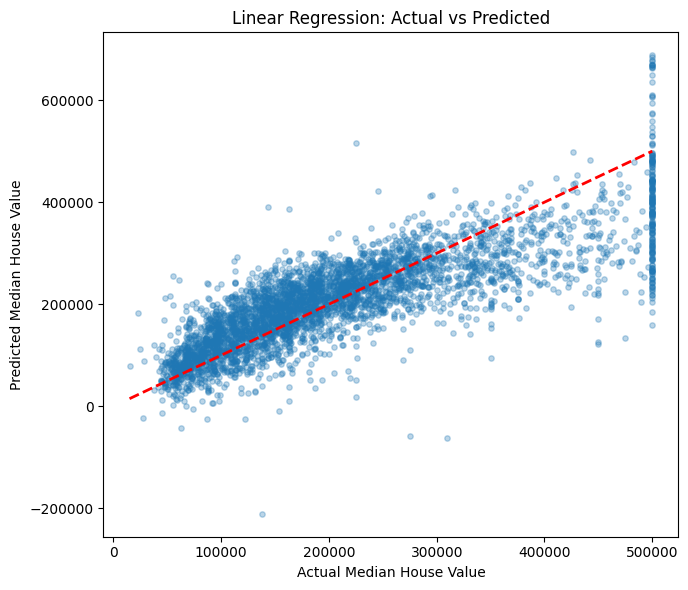

In [20]:
# Actual vs Predicted plot for Linear Regression
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_lr, alpha=0.3, s=15)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Median House Value')
plt.ylabel('Predicted Median House Value')
plt.title('Linear Regression: Actual vs Predicted')
plt.tight_layout()
save_and_show("linear_regression_actual_vs_predicted.png")


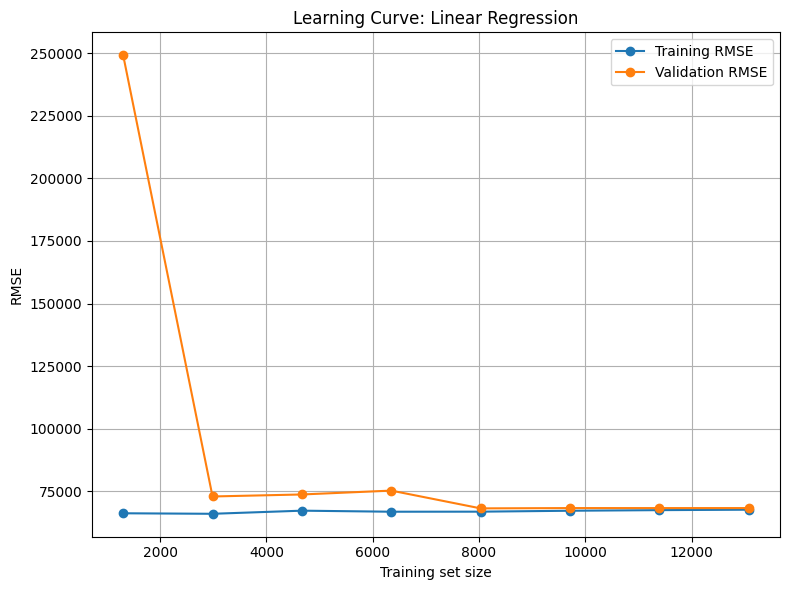

In [21]:
# Learning curves for the best Linear Regression model
ts, tr_s, val_s = learning_curve(best_lr, X_train_scaled, y_train,
                                  train_sizes=np.linspace(0.1, 1.0, 8),
                                  cv=kfold, scoring='neg_root_mean_squared_error', n_jobs=-1)
lr_learn_train_rmse, lr_learn_val_rmse = -tr_s.mean(axis=1), -val_s.mean(axis=1)

plt.figure(figsize=(8, 6))
plt.plot(ts, lr_learn_train_rmse, 'o-', label='Training RMSE')
plt.plot(ts, lr_learn_val_rmse, 'o-', label='Validation RMSE')
plt.xlabel('Training set size')
plt.ylabel('RMSE')
plt.title('Learning Curve: Linear Regression')
plt.legend()
plt.grid(True)
plt.tight_layout()
save_and_show("linear_regression_learning_curve.png")


## 3.2 Random Forest Regression

In [ ]:
"""
 Random Forest Regressor with RandomizedSearchCV
 with hyperparameter tuning using a downsampled training set for speed.
 
 Hyperparameters tuned:
 - n_estimators: Number of trees in the forest (100 to 300)
 - max_depth: Maximum depth of the tree (None, 10, 20)
 - min_samples_split: Minimum number of samples required to split an internal node (2 to 10)
 - min_samples_leaf: Minimum number of samples required to be at a leaf node (1 to 5)
 - max_features: Number of features to consider when looking for the best split (sqrt or all features)
 - bootstrap: Whether bootstrap samples are used when building trees (True)
 
"""

# Define the parameter distribution for RandomizedSearchCV
rf_param_dist = {
    'n_estimators': randint(100, 300),
    'max_depth': [None, 10, 20],
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 5),
    'max_features': ['sqrt', 1.0],
    'bootstrap': [True]
}

rf_random_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=rf_param_dist,
    n_iter=10,
    scoring='neg_root_mean_squared_error',
    cv=kfold,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_random_search.fit(X_train_scaled, y_train)

print("Best Random Forest params:", rf_random_search.best_params_)
print("Best CV RMSE: {:,.2f}".format(-rf_random_search.best_score_))

best_rf = rf_random_search.best_estimator_
y_pred_rf_train = best_rf.predict(X_search)
y_pred_rf = best_rf.predict(X_test_scaled)
evaluate_regression('Random Forest', y_search, y_pred_rf_train, y_test, y_pred_rf)

importances = pd.Series(best_rf.feature_importances_, index=regression_feature_names).sort_values(ascending=False)
print(importances)


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Random Forest params: {'bootstrap': True, 'max_depth': 20, 'max_features': 1.0, 'min_samples_leaf': 2, 'min_samples_split': 8, 'n_estimators': 289}
Best CV RMSE: 49,869.93

Random Forest Performance:
           RMSE       MAE      R2
Train  27782.18  17359.80  0.9412
Test   50398.49  32835.02  0.8124
median_income                 0.494076
ocean_proximity_INLAND        0.146180
population_per_household      0.124696
longitude                     0.056273
latitude                      0.053991
housing_median_age            0.040896
rooms_per_household           0.020890
bedrooms_per_room             0.020761
total_rooms                   0.010511
population                    0.009413
total_bedrooms                0.008866
households                    0.008384
ocean_proximity_NEAR OCEAN    0.003228
ocean_proximity_NEAR BAY      0.000640
CL_3                          0.000436
CL_1                          0.000369
CL_0    

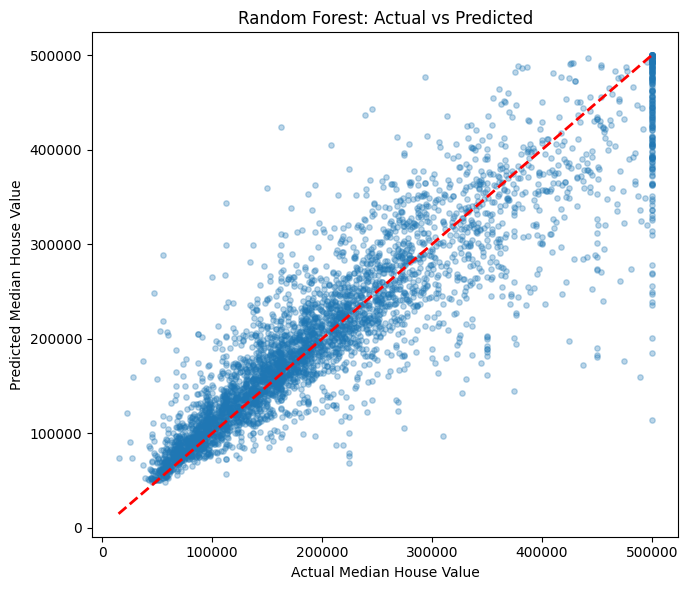

In [23]:
# Predict vs Actual plot for Random Forest
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.3, s=15)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Median House Value')
plt.ylabel('Predicted Median House Value')
plt.title('Random Forest: Actual vs Predicted')
plt.tight_layout()
save_and_show("random_forest_actual_vs_predicted.png")


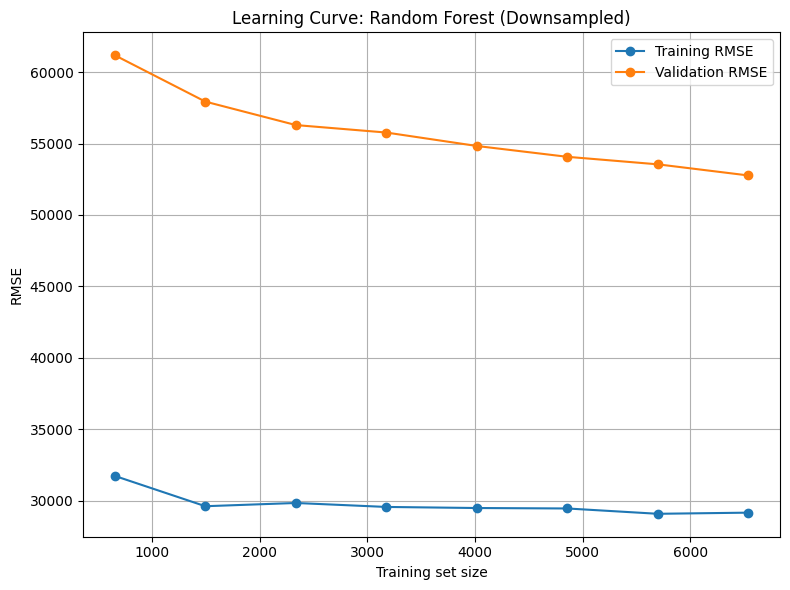

In [24]:
# Learning curves for the best Random Forest model (downsampled set)
ts, tr_s, val_s = learning_curve(best_rf, X_search, y_search,
                                  train_sizes=np.linspace(0.1, 1.0, 8),
                                  cv=kfold, scoring='neg_root_mean_squared_error', n_jobs=-1)
rf_learn_train_rmse, rf_learn_val_rmse = -tr_s.mean(axis=1), -val_s.mean(axis=1)

plt.figure(figsize=(8, 6))
plt.plot(ts, rf_learn_train_rmse, 'o-', label='Training RMSE')
plt.plot(ts, rf_learn_val_rmse, 'o-', label='Validation RMSE')
plt.xlabel('Training set size')
plt.ylabel('RMSE')
plt.title('Learning Curve: Random Forest (Downsampled)')
plt.legend()
plt.grid(True)
plt.tight_layout()
save_and_show("random_forest_learning_curve.png")


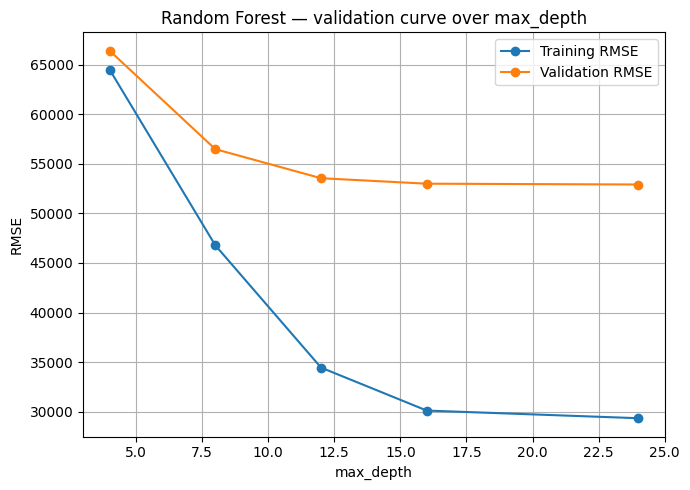

In [25]:
# Training vs cross-validation RMSE for Random Forest (full training set)
rf_fixed = {
    k: v for k, v in rf_random_search.best_params_.items()
    if k not in ("max_depth", "n_estimators")
}

depth_range = [4, 8, 12, 16, 24]

tr, va = validation_curve(
    RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        **rf_fixed
    ),
    X_search,
    y_search,
    param_name="max_depth",
    param_range=depth_range,
    cv=kfold,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

plt.figure(figsize=(7, 5))
plt.plot(depth_range, -tr.mean(axis=1), "o-", label="Training RMSE")
plt.plot(depth_range, -va.mean(axis=1), "o-", label="Validation RMSE")
plt.title("Random Forest — validation curve over max_depth")
plt.xlabel("max_depth")
plt.ylabel("RMSE")
plt.legend()
plt.grid(True)
plt.tight_layout()
save_and_show("random_forest_validation_curve.png")


## Support Vector Regression

In [ ]:
"""
    Support Vector Regression (SVR) with RandomizedSearchCV
    
    Hyperparameters tuned:
    - C: Regularization parameter (1e-1 to 1e2)
    - gamma: Kernel coefficient (1e-3 to 1e0)
    - epsilon: Epsilon in the epsilon-SVR model (0.01 to 0.3)
"""

y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train.values.reshape(-1, 1)).ravel()

svr_param_dist = {
    'C': loguniform(1e-1, 1e2),
    'gamma': loguniform(1e-3, 1e0),
    'epsilon': uniform(0.01, 0.3)
}

svr_random_search = RandomizedSearchCV(
    estimator=SVR(kernel='rbf'),
    param_distributions=svr_param_dist,
    n_iter=10,
    scoring='neg_root_mean_squared_error',
    cv=kfold,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

svr_random_search.fit(X_train_scaled, y_train_scaled)

print("Best SVR params:", svr_random_search.best_params_)
print("Best CV RMSE (scaled y): {:.4f}".format(-svr_random_search.best_score_))

best_svr = svr_random_search.best_estimator_
y_pred_svr_train_scaled = best_svr.predict(X_search)
y_pred_svr_train = y_scaler.inverse_transform(y_pred_svr_train_scaled.reshape(-1, 1)).ravel()
y_pred_svr = y_scaler.inverse_transform(best_svr.predict(X_test_scaled).reshape(-1, 1)).ravel()

evaluate_regression('SVR', y_search, y_pred_svr_train, y_test, y_pred_svr)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best SVR params: {'C': np.float64(1.3292918943162166), 'epsilon': np.float64(0.2952142919229748), 'gamma': np.float64(0.15702970884055384)}
Best CV RMSE (scaled y): 0.4800

SVR Performance:
           RMSE       MAE      R2
Train  49685.75  34007.26  0.8119
Test   55182.31  38046.13  0.7751


{'train': {'RMSE': np.float64(49685.74528433863),
  'MAE': 34007.257197633786,
  'R2': 0.8119158859845688},
 'test': {'RMSE': np.float64(55182.314807675546),
  'MAE': 38046.125836278705,
  'R2': 0.7750640901824144}}

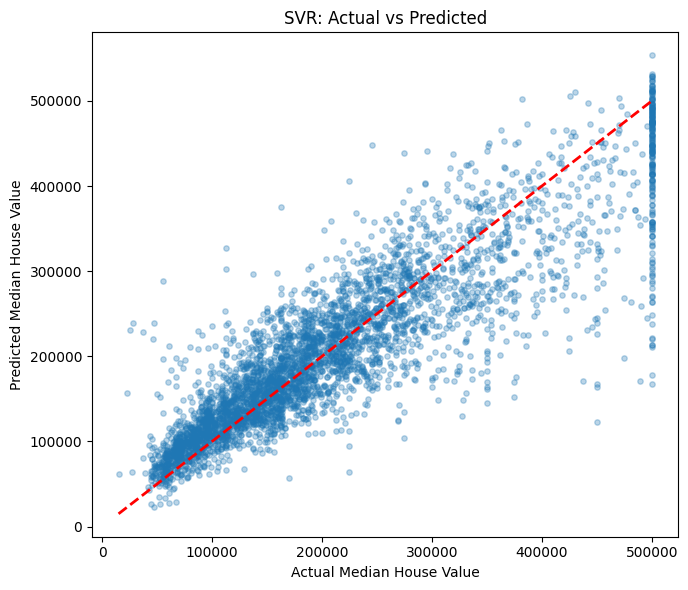

In [27]:
# Actual vs Predicted plot for SVR
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_svr, alpha=0.3, s=15)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Median House Value')
plt.ylabel('Predicted Median House Value')
plt.title('SVR: Actual vs Predicted')
plt.tight_layout()
save_and_show("svr_actual_vs_predicted.png")


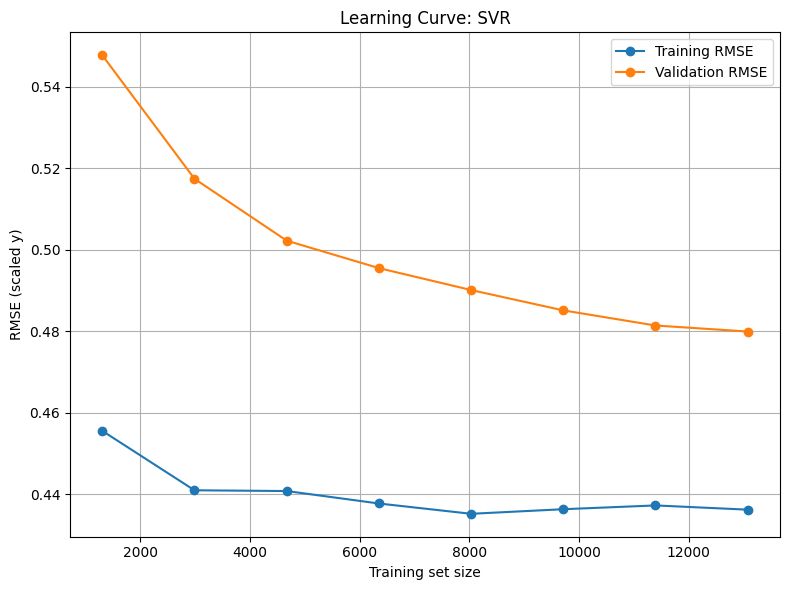

In [28]:
# Learning curves for the best SVR model
ts, tr_s, val_s = learning_curve(best_svr, X_train_scaled, y_train_scaled,
                                  train_sizes=np.linspace(0.1, 1.0, 8),
                                  cv=kfold, scoring='neg_root_mean_squared_error', n_jobs=-1)
svr_learn_train_rmse, svr_learn_val_rmse = -tr_s.mean(axis=1), -val_s.mean(axis=1)

plt.figure(figsize=(8, 6))
plt.plot(ts, svr_learn_train_rmse, 'o-', label='Training RMSE')
plt.plot(ts, svr_learn_val_rmse, 'o-', label='Validation RMSE')
plt.xlabel('Training set size')
plt.ylabel('RMSE (scaled y)')
plt.title('Learning Curve: SVR')
plt.legend()
plt.grid(True)
plt.tight_layout()
save_and_show("svr_learning_curve.png")


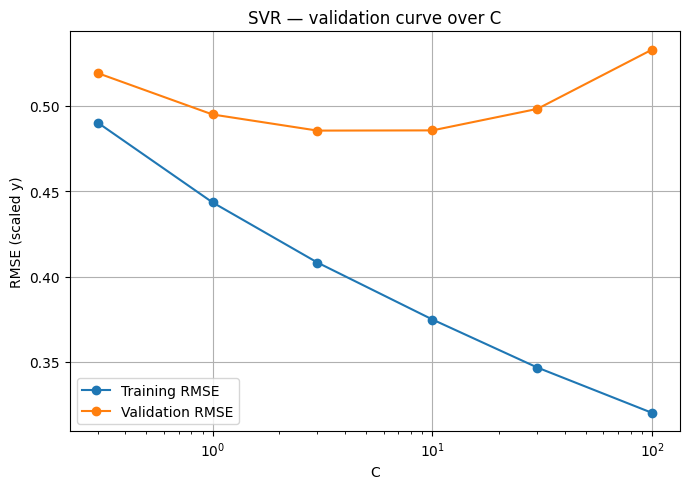

In [29]:
C_range = [0.3, 1, 3, 10, 30, 100]

tr, va = validation_curve(
    clone(best_svr),
    X_search,
    y_scaler.transform(y_search.values.reshape(-1, 1)).ravel(),
    param_name="C",
    param_range=C_range,
    cv=kfold,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

plt.figure(figsize=(7, 5))
plt.plot(C_range, -tr.mean(axis=1), "o-", label="Training RMSE")
plt.plot(C_range, -va.mean(axis=1), "o-", label="Validation RMSE")
plt.title("SVR — validation curve over C")
plt.xlabel("C")
plt.ylabel("RMSE (scaled y)")
plt.xscale("log")
plt.legend()
plt.grid(True)
plt.tight_layout()
save_and_show("svr_validation_curve.png")


In [30]:
# Summary table for the three regression models evaluated before MLP
summary_p1 = pd.DataFrame({
    model: {
        ('Train', 'RMSE'): metrics['train']['RMSE'],
        ('Train', 'MAE'): metrics['train']['MAE'],
        ('Train', 'R2'): metrics['train']['R2'],
        ('Test', 'RMSE'): metrics['test']['RMSE'],
        ('Test', 'MAE'): metrics['test']['MAE'],
        ('Test', 'R2'): metrics['test']['R2']
    }
    for model, metrics in regression_results.items()
}).T

summary_p1.columns = pd.MultiIndex.from_tuples(summary_p1.columns)
summary_p1 = summary_p1.reindex(columns=[
    ('Train', 'RMSE'), ('Train', 'MAE'), ('Train', 'R2'),
    ('Test', 'RMSE'), ('Test', 'MAE'), ('Test', 'R2')
]).round(3)

print('Performance on training and testing sets:')
print(summary_p1.to_string())

Performance on training and testing sets:
                       Train                         Test                  
                        RMSE        MAE     R2       RMSE        MAE     R2
Linear Regression  66579.709  48198.882  0.662  68103.338  49517.419  0.657
Random Forest      27782.176  17359.799  0.941  50398.492  32835.017  0.812
SVR                49685.745  34007.257  0.812  55182.315  38046.126  0.775


## Comparison

In [31]:
all_results_list = []
for model_name, metrics in regression_results.items():
    for split_name, split_metrics in metrics.items():
        record = {'model': model_name, 'split': split_name}
        record.update(split_metrics)
        all_results_list.append(record)

results_p1 = pd.DataFrame(all_results_list)

summary_p1 = (results_p1.pivot_table(index="model", columns="split",
                                     values=["RMSE", "MAE", "R2"])
              .reindex(["Linear Regression", "SVR", "Random Forest"])) # Ensure consistent order
summary_p1 = summary_p1[["RMSE", "MAE", "R2"]].round(3)
print("Performance on training and testing sets:")
summary_p1

summary_p1.to_csv("regression_models_performance.csv", index=True)

Performance on training and testing sets:


In [ ]:
# Bias–variance diagnosis
print("Bias–variance diagnosis (automatic):\n")
for model_name in ["Linear Regression", "SVR", "Random Forest"]:
    r = results_p1[results_p1["model"] == model_name]
    tr_rmse = float(r.loc[r["split"] == "train", "RMSE"].iloc[0])
    te_rmse = float(r.loc[r["split"] == "test", "RMSE"].iloc[0])
    te_r2 = float(r.loc[r["split"] == "test", "R2"].iloc[0])
    gap = (te_rmse - tr_rmse) / tr_rmse
    if te_r2 < 0.70 and gap < 0.15:
        verdict = "high bias -> UNDERFITTING tendency (both errors high, small gap)"
    elif gap > 0.30:
        verdict = "high variance -> OVERFITTING tendency (large train->test gap)"
    else:
        verdict = "reasonable bias-variance balance"
    print(f"{model_name:<18} train RMSE {tr_rmse:>9,.0f} | test RMSE {te_rmse:>9,.0f} "
          f"| gap {gap:+6.1%} | test R2 {te_r2:.3f}\n{'':<18} -> {verdict}\n")

Bias–variance diagnosis (automatic):

Linear Regression  train RMSE    66,580 | test RMSE    68,103 | gap  +2.3% | test R2 0.657
                   -> high bias -> UNDERFITTING tendency (both errors high, small gap)

SVR                train RMSE    49,686 | test RMSE    55,182 | gap +11.1% | test R2 0.775
                   -> reasonable bias-variance balance

Random Forest      train RMSE    27,782 | test RMSE    50,398 | gap +81.4% | test R2 0.812
                   -> high variance -> OVERFITTING tendency (large train->test gap)



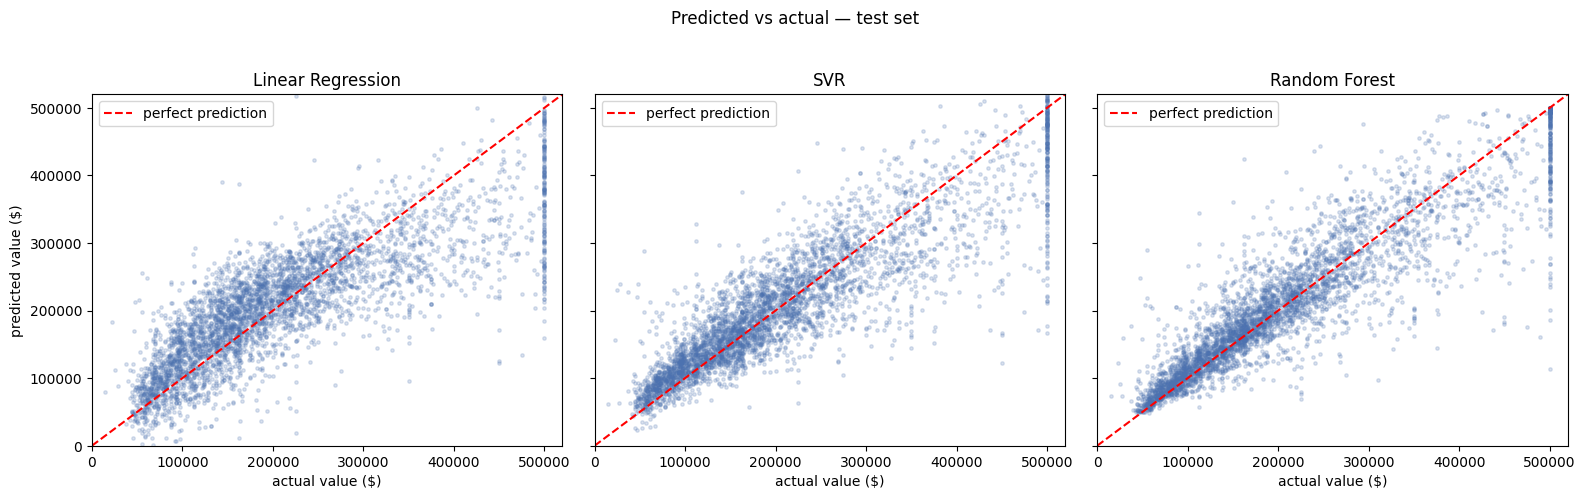

In [ ]:
# Predicted vs actual plots for the three regression models
model_names = ["Linear Regression", "SVR", "Random Forest"]

test_predictions = {
    "Linear Regression": y_pred_lr,
    "SVR": y_pred_svr,
    "Random Forest": y_pred_rf
}

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharey=True)
lims = [0, 520_000]
for ax, name in zip(axes, model_names):
    ax.scatter(y_test, test_predictions[name], s=6, alpha=0.2, color="#4C72B0")
    ax.plot(lims, lims, "r--", lw=1.5, label="perfect prediction")
    ax.set(title=name, xlabel="actual value ($)", xlim=lims, ylim=lims)
    ax.legend(loc="upper left")
axes[0].set_ylabel("predicted value ($)")
plt.suptitle("Predicted vs actual — test set", y=1.03)
plt.tight_layout()
save_and_show("predicted_vs_actual_test_set.png")


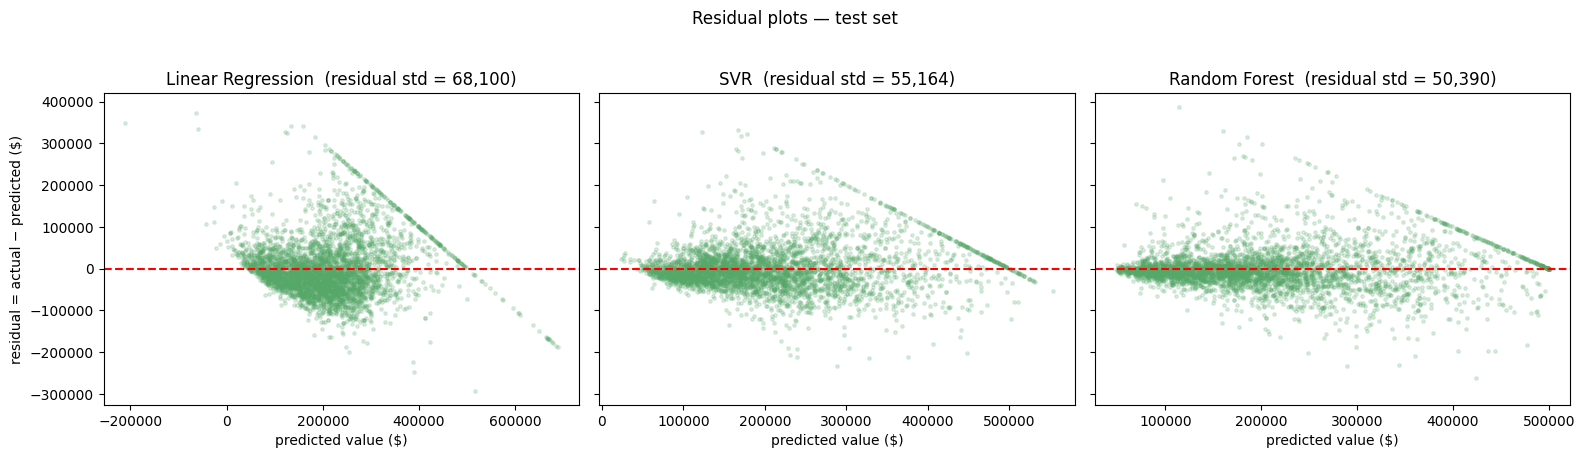

In [ ]:
# Residual plots for the three regression models
fig, axes = plt.subplots(1, 3, figsize=(16, 4.4), sharey=True)
for ax, name in zip(axes, model_names):
    res = y_test.to_numpy() - test_predictions[name]
    ax.scatter(test_predictions[name], res, s=6, alpha=0.2, color="#55A868")
    ax.axhline(0, color="red", ls="--", lw=1.5)
    ax.set(title=f"{name}  (residual std = {res.std():,.0f})",
           xlabel="predicted value ($)")
axes[0].set_ylabel("residual = actual − predicted ($)")
plt.suptitle("Residual plots — test set", y=1.03)
plt.tight_layout()
save_and_show("residual_plots_test_set.png")


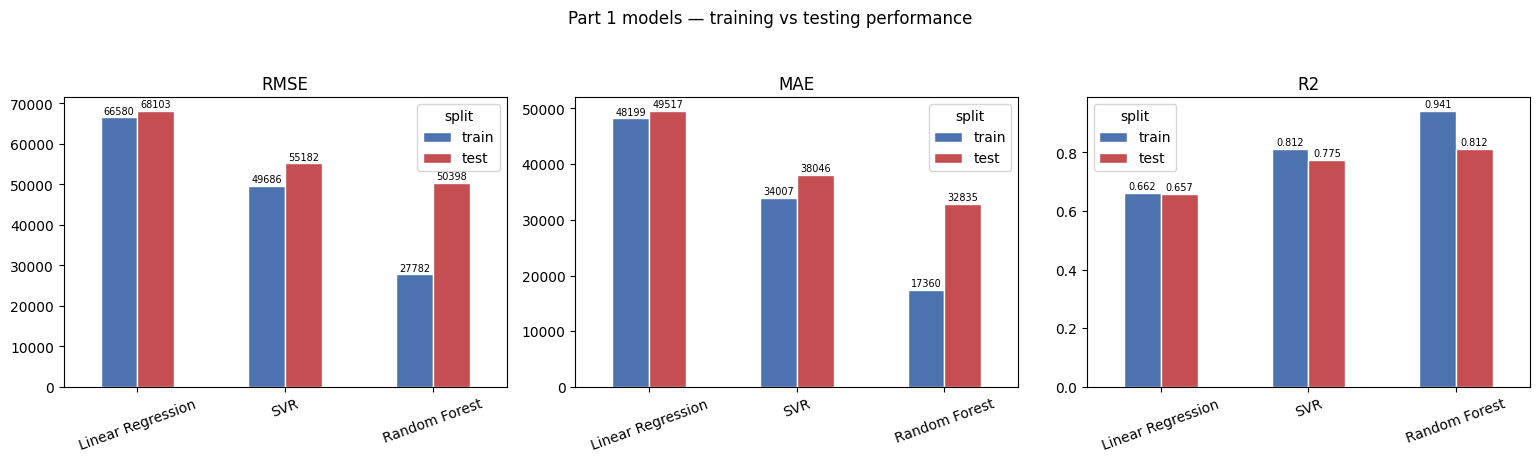

In [35]:
# Side by side matrix comparison of training vs testing performance for the three regression models
def plot_metric_comparison(results_frame, order, suptitle, filename=None):
    fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.4))
    for ax, metric in zip(axes, ["RMSE", "MAE", "R2"]):
        piv = (results_frame.pivot_table(index="model", columns="split", values=metric)
               .reindex(order))
        piv = piv[["train", "test"]]
        piv.plot(kind="bar", ax=ax, color=["#4C72B0", "#C44E52"], edgecolor="white")
        ax.set(title=metric, xlabel="")
        ax.tick_params(axis="x", rotation=20)
        for container in ax.containers:
            fmt = "%.3f" if metric == "R2" else "%.0f"
            ax.bar_label(container, fmt=fmt, fontsize=7, padding=1)
    plt.suptitle(suptitle, y=1.04)
    plt.tight_layout()
    if filename is not None:
        plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

plot_metric_comparison(
    results_p1,
    model_names,
    "Part 1 models — training vs testing performance",
    filename="regression_models_performance_comparison.png"
)


## MLP

In [ ]:
"""
   MLP model for regression with 3 hidden layers, L2 regularization on weights, and dropout on activations.
   The model is built using Keras Sequential API and compiled with Adam optimizer and mean squared error loss function.
   
   Achitecture:
   - Input layer: number of features in the dataset
   - Hidden layer 1: 128 neurons, ReLU activation, L2 regularization
   - Dropout layer: 20% dropout rate
   - Hidden layer 2: 64 neurons, ReLU activation, L2 regularization
   - Dropout layer: 20% dropout rate
   - Hidden layer 3: 32 neurons, ReLU activation, L2 regularization
   - Dropout layer: 20% dropout rate
   - Output layer: 1 neuron (for regression output)
"""

y_train_arr = np.asarray(y_train).ravel()
y_test_arr = np.asarray(y_test).ravel()

# Use the full training set for MLP (no downsampling)
X_train_mlp = X_train_scaled
y_train_mlp = y_train_arr

# Standardise features for MLP (fit on full training set)
scaler = StandardScaler()
X_train_mlp_scaled = scaler.fit_transform(X_train_mlp)
X_test_mlp_scaled = scaler.transform(X_test_scaled)

print(f"MLP training samples used: {X_train_mlp_scaled.shape[0]}")

# Building the MLP model
dropout_rate = 0.2  # Dropout rate for regularization
mlp_learning_rate = 0.001  # Learning rate for the optimizer

def build_mlp_model(input_dim, dropout_rate=0.3, lr=1e-3, l2_lambda=1e-4):
    model = Sequential()

    model.add(Input(shape=(input_dim,)))

    # Hidden layer 1 — L2 on weights + dropout on activations
    model.add(Dense(128, activation='relu',
                    kernel_regularizer=l2(l2_lambda)))
    model.add(Dropout(dropout_rate))

    # Hidden layer 2
    model.add(Dense(64, activation='relu',
                    kernel_regularizer=l2(l2_lambda)))
    model.add(Dropout(dropout_rate))

    # Hidden layer 3
    model.add(Dense(32, activation='relu',
                    kernel_regularizer=l2(l2_lambda)))
    model.add(Dropout(dropout_rate))

    # Output layer — single linear neuron for regression
    model.add(Dense(1))

    optimizer = Adam(learning_rate=lr)
    model.compile(optimizer=optimizer,
                  loss='mean_squared_error',
                  metrics=['mean_absolute_error', 'mean_squared_error'])
    return model



MLP training samples used: 16346


In [ ]:
# Hyperparameter tuning for MLP using K-fold cross-validation
# Hyperparameters to tune: dropout_rate, learning rate (lr), and L2 regularization strength (l2_lambda)
param_grid = {
    'dropout_rate': [0.2, 0.3],
    'lr': [0.001,0.0001],
    'l2_lambda': [1e-4, 1e-5]
}

from sklearn.model_selection import ParameterGrid

best_params = None
best_val_loss = float('inf')

# Running K-fold cross-validation for hyperparameter tuning
for params in ParameterGrid(param_grid):
    print(f"Training with params: {params}")
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    val_losses = []

    for train_index, val_index in kf.split(X_train_mlp_scaled):
        X_train_fold, X_val_fold = X_train_mlp_scaled[train_index], X_train_mlp_scaled[val_index]
        y_train_fold, y_val_fold = y_train_mlp[train_index], y_train_mlp[val_index]

        model = build_mlp_model(input_dim=X_train_mlp_scaled.shape[1],
                                dropout_rate=params['dropout_rate'],
                                lr=params['lr'],
                                l2_lambda=params['l2_lambda'])

        early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
        history = model.fit(X_train_fold, y_train_fold,
                            validation_data=(X_val_fold, y_val_fold),
                            epochs=100,
                            batch_size=126,
                            callbacks=[early_stopping],
                            verbose=0)

        val_loss = min(history.history['val_loss'])
        val_losses.append(val_loss)

    avg_val_loss = np.mean(val_losses)
    print(f"Average validation loss: {avg_val_loss}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_params = params

print(f"Best params: {best_params}")
print(f"Best validation loss: {best_val_loss}")

Training with params: {'dropout_rate': 0.2, 'l2_lambda': 0.0001, 'lr': 0.001}
Average validation loss: 3931859046.4
Training with params: {'dropout_rate': 0.2, 'l2_lambda': 0.0001, 'lr': 0.0001}
Average validation loss: 6633466777.6
Training with params: {'dropout_rate': 0.2, 'l2_lambda': 1e-05, 'lr': 0.001}
Average validation loss: 3924252416.0
Training with params: {'dropout_rate': 0.2, 'l2_lambda': 1e-05, 'lr': 0.0001}
Average validation loss: 6538279526.4
Training with params: {'dropout_rate': 0.3, 'l2_lambda': 0.0001, 'lr': 0.001}
Average validation loss: 3970518220.8
Training with params: {'dropout_rate': 0.3, 'l2_lambda': 0.0001, 'lr': 0.0001}
Average validation loss: 6530990080.0
Training with params: {'dropout_rate': 0.3, 'l2_lambda': 1e-05, 'lr': 0.001}
Average validation loss: 3978507571.2
Training with params: {'dropout_rate': 0.3, 'l2_lambda': 1e-05, 'lr': 0.0001}
Average validation loss: 6694338457.6
Best params: {'dropout_rate': 0.2, 'l2_lambda': 1e-05, 'lr': 0.001}
Best

In [38]:
# Best configuration table
best_config_table = pd.DataFrame([best_params])
best_config_table.to_csv("mlp_best_config.csv", index=False)


In [ ]:
# KFold Cross-Validation for the best MLP model
kf = KFold(n_splits=5, shuffle=True, random_state=42)
val_losses = []
fold_histories = []

for train_index, val_index in kf.split(X_train_mlp_scaled):
    X_train_fold, X_val_fold = X_train_mlp_scaled[train_index], X_train_mlp_scaled[val_index]
    y_train_fold, y_val_fold = y_train_mlp[train_index], y_train_mlp[val_index]

    fold_model = build_mlp_model(
        input_dim=X_train_mlp_scaled.shape[1],
        dropout_rate=best_params['dropout_rate'],
        lr=best_params['lr'],
        l2_lambda=best_params['l2_lambda']
    )

    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    fold_history = fold_model.fit(
        X_train_fold, y_train_fold,
        validation_data=(X_val_fold, y_val_fold),
        epochs=100,
        batch_size=32,
        callbacks=[early_stopping],
        verbose=0
    )

    val_loss = min(fold_history.history['val_loss'])
    val_losses.append(val_loss)
    fold_histories.append(fold_history.history)

print(f"CV validation losses: {val_losses}")
print(f"Mean CV validation loss: {np.mean(val_losses):.4f}")

# Train the final best_model on the FULL training set (used later for
# predictions, learning curve, and evaluation)
best_model = build_mlp_model(
    input_dim=X_train_mlp_scaled.shape[1],
    dropout_rate=best_params['dropout_rate'],
    lr=best_params['lr'],
    l2_lambda=best_params['l2_lambda']
)

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = best_model.fit(
    X_train_mlp_scaled, y_train_mlp,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=0
)

CV validation losses: [4058381824.0, 3786664960.0, 3599182336.0, 3619245312.0, 3633488640.0]
Mean CV validation loss: 3739392614.4000


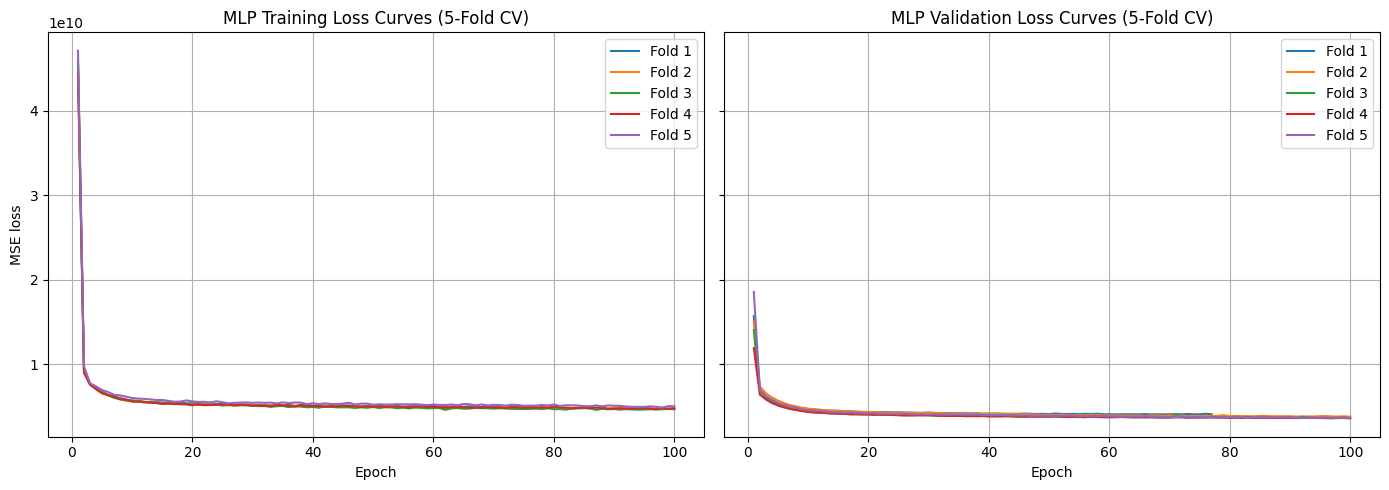

128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


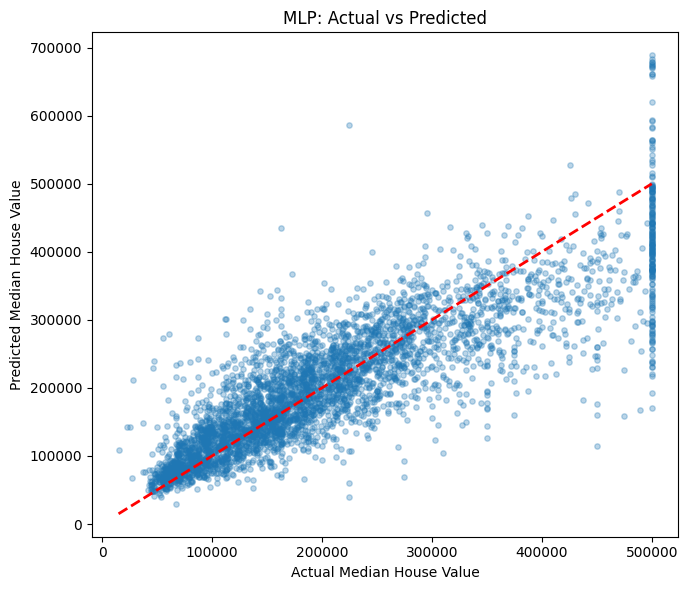

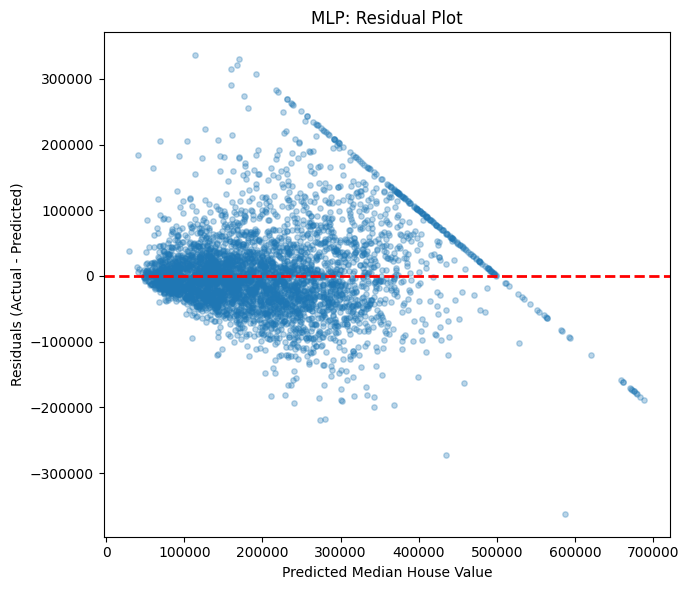

511/511 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Training RMSE: 60451.2482, MAE: 42029.3164, R^2: 0.7246
Test RMSE: 61786.1955, MAE: 43196.3906, R^2: 0.7180
Performance on training and testing sets (all models incl. MLP):


Train                         Test                  
                        RMSE        MAE     R2       RMSE        MAE     R2
Linear Regression  66579.709  48198.882  0.662  68103.338  49517.419  0.657
SVR                49685.745  34007.257  0.812  55182.315  38046.126  0.775
Random Forest      27782.176  17359.799  0.941  50398.492  32835.017  0.812
MLP                60451.248  42029.316  0.725  61786.195  43196.391  0.718

In [ ]:
"""
 Visualization of the MLP model's learning curves (training and validation loss vs epochs) for all 5 folds of K-fold cross-validation.
 
 Including:
    - Training loss curves for each fold
    - Validation loss curves for each fold
    - Actual vs Predicted plot for the best MLP model on the test set
    - Residual plot for the best MLP model on the test set
    - Evaluation metrics (RMSE, MAE, R^2) for the best MLP model on both training and test sets
"""

# Plot all 5 K-fold MLP learning curves (training and validation loss vs epochs)
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for i, hist in enumerate(fold_histories, start=1):
    axes[0].plot(range(1, len(hist["loss"]) + 1), hist["loss"], label=f"Fold {i}")
    axes[1].plot(range(1, len(hist["val_loss"]) + 1), hist["val_loss"], label=f"Fold {i}")

axes[0].set_title("MLP Training Loss Curves (5-Fold CV)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE loss")
axes[0].legend()
axes[0].grid(True)

axes[1].set_title("MLP Validation Loss Curves (5-Fold CV)")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
save_and_show("mlp_kfold_learning_curves.png")

# Plot Actual vs Predicted for the best MLP model
y_pred_mlp = best_model.predict(X_test_mlp_scaled).ravel()
plt.figure(figsize=(7, 6))
plt.scatter(y_test_arr, y_pred_mlp, alpha=0.3, s=15)
plt.plot([y_test_arr.min(), y_test_arr.max()], [y_test_arr.min(), y_test_arr.max()], 'r--', lw=2)
plt.xlabel('Actual Median House Value')
plt.ylabel('Predicted Median House Value')
plt.title('MLP: Actual vs Predicted')
plt.tight_layout()
save_and_show("mlp_actual_vs_predicted.png")

# Residual plot for the best MLP model
residuals_mlp = y_test_arr - y_pred_mlp
plt.figure(figsize=(7, 6))
plt.scatter(y_pred_mlp, residuals_mlp, alpha=0.3, s=15)
plt.axhline(0, color='red', linestyle='--', lw=2)
plt.xlabel('Predicted Median House Value')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('MLP: Residual Plot')
plt.tight_layout()
save_and_show("mlp_residual_plot.png")

# Evaluation of the best MLP model on the training and test sets (RMSE, MAE, R^2)
y_pred_mlp_train = best_model.predict(X_train_mlp_scaled).ravel()
rmse_train = np.sqrt(mean_squared_error(y_train_mlp, y_pred_mlp_train))
mae_train = mean_absolute_error(y_train_mlp, y_pred_mlp_train)
r2_train = r2_score(y_train_mlp, y_pred_mlp_train)

y_pred_mlp_test = best_model.predict(X_test_mlp_scaled).ravel()
rmse_test = np.sqrt(mean_squared_error(y_test_arr, y_pred_mlp_test))
mae_test = mean_absolute_error(y_test_arr, y_pred_mlp_test)
r2_test = r2_score(y_test_arr, y_pred_mlp_test)

print(f"Training RMSE: {rmse_train:.4f}, MAE: {mae_train:.4f}, R^2: {r2_train:.4f}")
print(f"Test RMSE: {rmse_test:.4f}, MAE: {mae_test:.4f}, R^2: {r2_test:.4f}")

# Summary table for all models
mlp_metrics = {
    'train': {'RMSE': rmse_train, 'MAE': mae_train, 'R2': r2_train},
    'test':  {'RMSE': rmse_test,  'MAE': mae_test,  'R2': r2_test}
}

all_results = dict(regression_results)
all_results['MLP'] = mlp_metrics

summary_p2 = pd.DataFrame({
    model: {
        ('Train', 'RMSE'): metrics['train']['RMSE'],
        ('Train', 'MAE'): metrics['train']['MAE'],
        ('Train', 'R2'): metrics['train']['R2'],
        ('Test', 'RMSE'): metrics['test']['RMSE'],
        ('Test', 'MAE'): metrics['test']['MAE'],
        ('Test', 'R2'): metrics['test']['R2']
    }
    for model, metrics in all_results.items()
}).T

summary_p2.columns = pd.MultiIndex.from_tuples(summary_p2.columns)
summary_p2 = summary_p2.reindex(
    ["Linear Regression", "SVR", "Random Forest", "MLP"],
    columns=[
        ('Train', 'RMSE'), ('Train', 'MAE'), ('Train', 'R2'),
        ('Test', 'RMSE'), ('Test', 'MAE'), ('Test', 'R2')
    ]
).round(3)

print("Performance on training and testing sets (all models incl. MLP):")
display(summary_p2)

summary_p2.to_csv("all_models_performance_incl_mlp.csv", index=True)


In [44]:
# Save trained models (simple one-cell export)
save_dir = Path("saved_models")
save_dir.mkdir(parents=True, exist_ok=True)

saved = []


def save_joblib_if_exists(var_name, filename):
    if var_name in globals() and globals()[var_name] is not None:
        out = save_dir / filename
        joblib.dump(globals()[var_name], out)
        saved.append(str(out))


# KMeans (supports either variable name used in notebook)
if "kmeans" in globals() and globals()["kmeans"] is not None:
    save_joblib_if_exists("kmeans", "KMeans.pkl")
elif "kmeans_final" in globals() and globals()["kmeans_final"] is not None:
    save_joblib_if_exists("kmeans_final", "KMeans.pkl")

# Regression and KNN models
save_joblib_if_exists("best_lr", "LR.pkl")
save_joblib_if_exists("best_svr", "SVR.pkl")
save_joblib_if_exists("best_rf", "RF.pkl")
save_joblib_if_exists("knn", "KNN.pkl")

# MLP model
if "best_model" in globals() and globals()["best_model"] is not None:
    mlp_out = save_dir / "MLP.keras"
    globals()["best_model"].save(mlp_out)
    saved.append(str(mlp_out))

if saved:
    print("Saved models:")
    for p in saved:
        print("-", p)
else:
    print("No trained model objects found. Run training cells first.")

Saved models:
- saved_models/KMeans.pkl
- saved_models/LR.pkl
- saved_models/SVR.pkl
- saved_models/RF.pkl
- saved_models/KNN.pkl
- saved_models/MLP.keras
